# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [3]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"

import pandas as pd

pd.__version__

'2.2.2'

---
## Student Information

In [4]:
# <Student to fill this section>
student_name = "Nishaanth Govindaraj"
student_id = "26044382"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

In [7]:
# <Student to fill this section>
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import matplotlib.pyplot as plt
from joblib import dump

from my_krml_26044382.data.weather import load_hourly_weather_years, aggregate_daily
from my_krml_26044382.data.sets import split_sets_by_time
from my_krml_26044382.features.targets import add_target_columns, create_future_targets, cci_to_label
from my_krml_26044382.features.build import build_features, get_feature_columns, REQUIRED_HISTORY_DAYS
from my_krml_26044382.models.performance import print_regressor_scores

---
## A. Project Description




In [8]:
# <Student to fill this section>
business_use_case_description = """
Open-Meteo is adding AI-powered weather intelligence services to its microservice platform. This project builds a
forecasting service that predicts the Climate Comfort Index (CCI) for Sydney for each of the next 3 days. The CCI
(0 to 100) summarises how suitable the weather is for outdoor activities by combining temperature, humidity, wind,
cloud cover and rainfall into one easy-to-read score.

The service will be exposed through a REST API so that consumer apps, tourism and events businesses can plan
outdoor activities in advance.

Hypothesis for this experiment: a regularised linear model (Ridge regression) trained on today's weather,
lagged values, rolling averages and seasonal features can predict the CCI for the next 3 days more accurately
(lower RMSE) than two simple baselines: persistence (tomorrow = today) and monthly climatology (the average CCI
for that month).
"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
# <Student to fill this section>
business_objectives = """
Accurate forecasts let users and businesses plan outdoor activities (events, tours, sport, hospitality staffing)
on the most comfortable days, and prepare alternatives for uncomfortable days.

Impact of accurate results: better event scheduling, fewer cancellations, higher customer satisfaction and
trust in the Open-Meteo platform.

Impact of incorrect results:
- Over-estimating comfort: an event is scheduled on a day that turns out uncomfortable or rainy, leading to
  cancellations, refunds, poor attendance or safety concerns. This is the more costly error.
- Under-estimating comfort: good days are missed, causing lost revenue and unnecessary rescheduling.

Success criterion: the model must beat both baselines on the validation set for all three horizons, with errors
small enough that the forecast usually falls in the correct CCI interpretation band.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Users of the predictions:
- Developers of apps and websites that consume the Open-Meteo API.
- Tourism operators, event organisers, sports clubs and hospitality businesses planning outdoor activities.
- Members of the public checking whether the next days suit outdoor plans.

People impacted by the predictions:
- Event attendees and customers, whose plans depend on the forecast.
- Staff whose rosters may be set from the forecast.
- The Open-Meteo business, whose reputation depends on forecast reliability.

Expectations: forecasts must be available on demand through the API, easy to interpret (the CCI bands from
Excellent to Very poor), and transparent about their accuracy, which is expected to decrease from day 1 to day 3.
"""

In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Raw Data


In [14]:
# <Student to fill this section>
df_hourly = load_hourly_weather_years(2000, 2025, cache_dir='../../data/raw/yearly')
df_daily = aggregate_daily(df_hourly)

print(df_hourly.shape, df_daily.shape)
print(df_daily['date'].min(), df_daily['date'].max())

2000: loaded from cache
2001: loaded from cache
2002: loaded from cache
2003: loaded from cache
2004: loaded from cache
2005: loaded from cache
2006: loaded from cache
2007: loaded from cache
2008: loaded from cache
2009: loaded from cache
2010: loaded from cache
2011: loaded from cache
2012: loaded from cache
2013: loaded from cache
2014: loaded from cache
2015: loaded from cache
2016: loaded from cache
2017: loaded from cache
2018: loaded from cache
2019: loaded from cache
2020: loaded from cache
2021: loaded from cache
2022: loaded from cache
2023: loaded from cache
2024: loaded from cache
2025: loaded from cache
(227928, 13) (9497, 20)
2000-01-01 00:00:00 2025-12-31 00:00:00


### C.2 Define Target variable

In [15]:
# <Student to fill this section>
cci_inputs = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'cloud_cover', 'precipitation']
df_daily[cci_inputs].describe().T[['mean', 'min', 'max']]

,mean,min,max
temperature_2m,17.475345,7.625000,30.904167
relative_humidity_2m,71.705385,23.875000,96.041667
wind_speed_10m,11.391030,3.308333,37.387500
cloud_cover,47.379286,0.000000,100.000000
precipitation,2.159324,0.000000,138.400000


In [16]:
# <Student to fill this section>
target_definition_explanations = """
The target is the Climate Comfort Index (CCI), calculated with the formula defined by the business:
CCI = 100 x (0.35 TempScore + 0.20 HumidityScore + 0.15 WindScore + 0.15 CloudScore + 0.15 RainScore).
Each component score is 1 at ideal conditions (22 degC, 50 percent humidity, 10 km/h wind, no cloud, no rain)
and decreases to 0 as conditions move away from ideal.

Data granularity: hourly Open-Meteo observations for Sydney (lat -33.8688, lon 151.2093) are aggregated to daily
values as required: daily mean temperature, humidity, wind speed and cloud cover, and daily total precipitation.

Prediction target: the model predicts the CCI of each of the next 3 days (t+1, t+2, t+3) using only information
available at the end of day t. One Ridge model is trained per horizon, so each horizon gets its own coefficients
and its accuracy can be reported separately.

Only data up to 31 December 2025 is used. Data from 2026 onwards is reserved for production.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable



In [18]:
# <Student to fill this section>
df_daily = add_target_columns(df_daily)
df_daily = create_future_targets(df_daily, 'cci', [1, 2, 3])

target_name = 'cci'
target_cols = ['cci_t_plus_1', 'cci_t_plus_2', 'cci_t_plus_3']

df_daily[['date', 'cci'] + target_cols].head()

,date,cci,cci_t_plus_1,cci_t_plus_2,cci_t_plus_3
0,2000-01-01,68.708854,64.879688,80.012500,81.783333
1,2000-01-02,64.879688,80.012500,81.783333,88.359375
2,2000-01-03,80.012500,81.783333,88.359375,82.728646
3,2000-01-04,81.783333,88.359375,82.728646,74.003125
4,2000-01-05,88.359375,82.728646,74.003125,71.151042


### C.4 Explore Target variable

count    9497.000000
mean       72.603870
std        10.154340
min        28.634375
25%        67.090104
50%        73.615104
75%        79.393229
max        98.889583
Name: cci, dtype: float64
cci
Comfortable conditions          6271
Excellent outdoor conditions    2191
Moderate comfort                 983
Poor comfort                      52
Name: count, dtype: int64


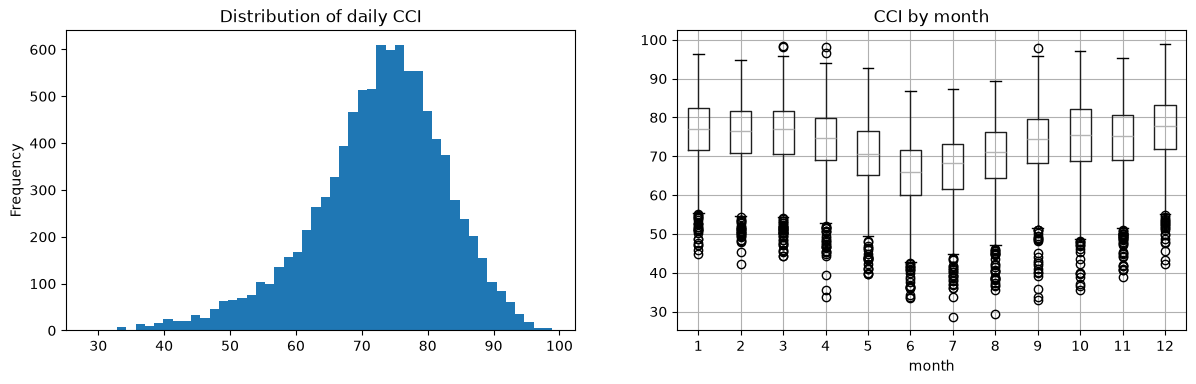

In [19]:
# <Student to fill this section>
print(df_daily['cci'].describe())
print(df_daily['cci'].apply(cci_to_label).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_daily['cci'].plot(kind='hist', bins=50, ax=axes[0], title='Distribution of daily CCI')
df_daily.assign(month=df_daily['date'].dt.month).boxplot(column='cci', by='month', ax=axes[1])
axes[1].set_title('CCI by month')
plt.suptitle('')
plt.show()

In [20]:
for lag in [1, 2, 3, 7, 365]:
    print(f"Autocorrelation lag {lag}: {df_daily['cci'].autocorr(lag=lag):.3f}")

Autocorrelation lag 1: 0.605
Autocorrelation lag 2: 0.376
Autocorrelation lag 3: 0.289
Autocorrelation lag 7: 0.201
Autocorrelation lag 365: 0.149


In [ ]:
# <Student to fill this section>
target_distribution_explanations = """
Distribution: Sydney is mostly comfortable. Out of 9,497 days, 6,271 are Comfortable (60-79), 2,191 are
Excellent (80-100), 983 are Moderate (40-59) and only 52 are Poor (20-39). No day falls in the Very poor band
(minimum CCI 28.6, maximum 98.9). The target is therefore concentrated between 40 and 100, and the model has
little data to learn the rare low-comfort days.

Seasonality: comfort is highest in summer (December 76.9 and January 76.4 on average) and lowest in winter
(June 65.0 and July 66.7). Winter days in Sydney are further from the ideal 22 degC, which lowers the
temperature score, the component with the largest weight (0.35).

Autocorrelation: today's CCI is moderately related to tomorrow's (0.605), but the relationship weakens quickly
(0.376 at 2 days, 0.289 at 3 days, 0.201 at 7 days). This means:
- the day-1 forecast should be the most accurate and the day-3 forecast noticeably less accurate;
- lag and rolling features should help, especially for day 1;
- a simple persistence forecast will degrade quickly with the horizon.

Limitations: the CCI is a deterministic formula of daily averages, so short but severe events (e.g. a 1-hour
storm) are smoothed out. The upper range is capped at 100 and the lower range is rarely reached in Sydney.
"""

In [22]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `cloud_cover`

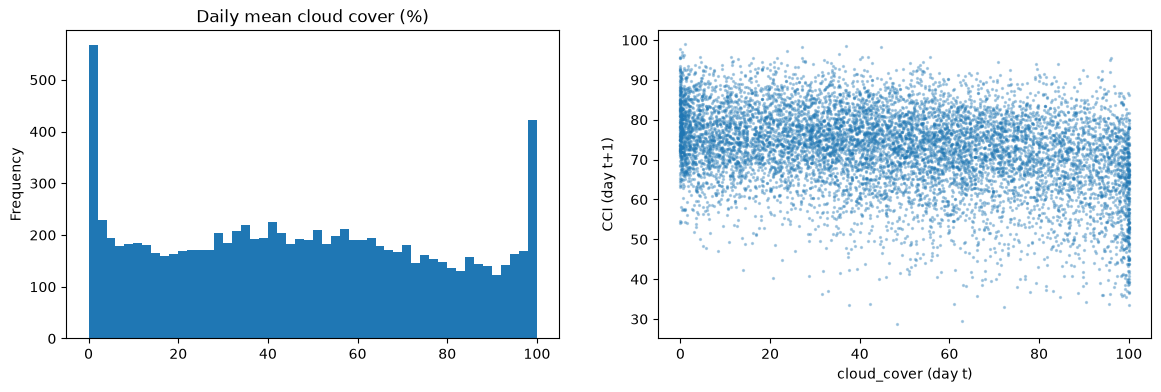

In [23]:
# <Student to fill this section>
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_daily['cloud_cover'].plot(kind='hist', bins=50, ax=axes[0], title='Daily mean cloud cover (%)')
axes[1].scatter(df_daily['cloud_cover'], df_daily['cci_t_plus_1'], s=2, alpha=0.3)
axes[1].set_xlabel('cloud_cover (day t)')
axes[1].set_ylabel('CCI (day t+1)')
plt.show()

In [24]:
print(f"Correlation with same-day CCI: {df_daily['cloud_cover'].corr(df_daily['cci']):.3f}")
print(f"Correlation with next-day CCI: {df_daily['cloud_cover'].corr(df_daily['cci_t_plus_1']):.3f}")

Correlation with same-day CCI: -0.644
Correlation with next-day CCI: -0.320


In [ ]:
# <Student to fill this section>
feature_1_insights = """
Cloud cover has the strongest same-day relationship with the CCI among the raw weather variables
(correlation -0.644): cloudy days are less comfortable, both directly (CloudScore) and because cloud usually
comes with rain and humidity.

The relationship with next-day CCI is much weaker (-0.320), showing that today's cloud only partly predicts
tomorrow's comfort. The scatter plot confirms a downward trend with a lot of spread: fully overcast days are
followed by a wide range of CCI values, including most of the lowest ones (below 40).

Distribution: the histogram is U-shaped, with two peaks at completely clear days (0 percent, about 570 days)
and fully overcast days (100 percent, about 420 days), and a flat spread in between. The daily mean is
therefore not normally distributed, which suits tree-based models better than linear ones.

Limitation: a daily mean hides the timing of cloud (a cloudy morning and a sunny afternoon give the same value).
Rolling averages of cloud cover over 3 to 30 days are used later to capture persistent cloudy periods.
"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `precipitation`

Share of dry days: 0.507
0.50     0.0
0.90     5.8
0.99    29.7
Name: precipitation, dtype: float64
precipitation
False    75.0
True     70.1
Name: cci_t_plus_1, dtype: float64


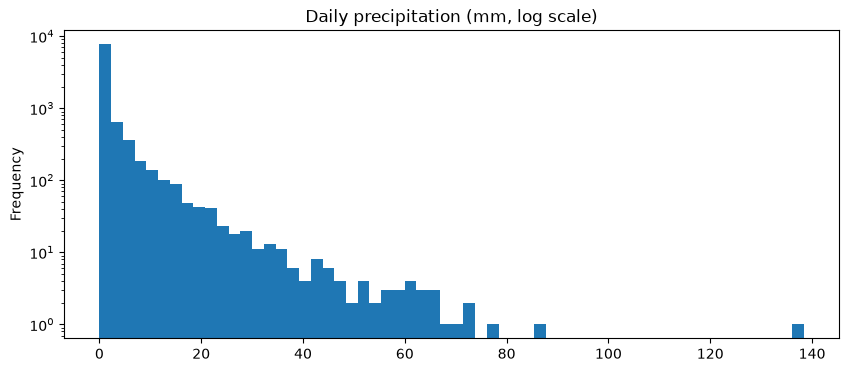

In [27]:
# <Student to fill this section>
print(f"Share of dry days: {(df_daily['precipitation'] == 0).mean():.3f}")
print(df_daily['precipitation'].quantile([0.5, 0.9, 0.99]).round(1))
print(df_daily.groupby(df_daily['precipitation'] > 0)['cci_t_plus_1'].mean().round(1))

df_daily['precipitation'].plot(kind='hist', bins=60, figsize=(10, 4), log=True,
                               title='Daily precipitation (mm, log scale)')
plt.show()

In [ ]:
# <Student to fill this section>
feature_2_insights = """
Precipitation is highly skewed: 50.7 percent of days are completely dry, the median is 0.0 mm, 90 percent of
days have 5.8 mm or less, and only 1 percent exceed 29.7 mm (maximum 138.4 mm). A log scale is needed to see
the distribution.

Rain lowers the CCI through the RainScore (20 mm or more gives a score of 0) and is strongly linked to humidity
and cloud. Its same-day correlation with CCI is -0.584 and the number of rainy hours has an even stronger link
(-0.674). Rain also carries over to the next day: the average CCI the day after a wet day is 70.1, compared
with 75.0 after a dry day.

Limitation: the rain component uses daily totals, so it does not distinguish a short shower from a full day of
rain. Rolling rainfall totals over 3 to 30 days are added to capture wet spells.
"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `month` (seasonality)

In [30]:
# <Student to fill this section>
monthly = df_daily.groupby(df_daily['date'].dt.month)['cci'].agg(['mean', 'std']).round(1)
monthly.T

date,1,2,3,4,5,6,7,8,9,10,11,12
mean,76.4,75.4,75.3,73.8,70.0,65.0,66.7,69.6,73.6,74.6,74.0,76.9
std,8.8,9.0,9.5,9.1,9.3,9.3,9.1,9.6,9.9,10.6,10.2,9.0


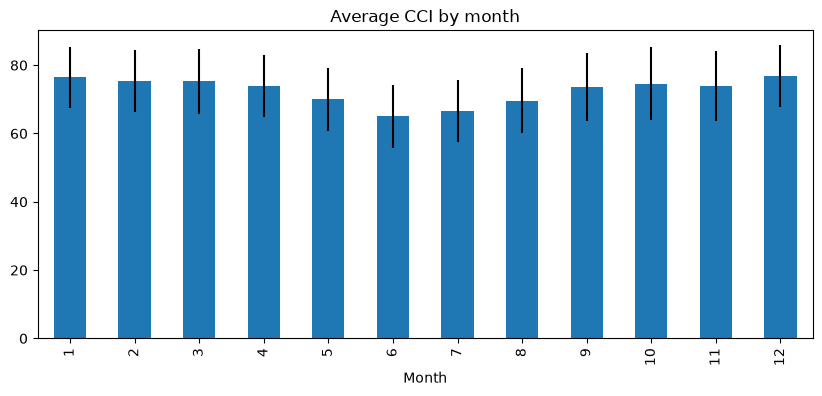

In [31]:
monthly['mean'].plot(kind='bar', yerr=monthly['std'], figsize=(10, 4), title='Average CCI by month')
plt.xlabel('Month')
plt.show()

In [ ]:
# <Student to fill this section>
feature_n_insights = """
The average CCI changes clearly with the season: December (76.9), January (76.4) and February (75.4) have the
highest average comfort, and June (65.0), July (66.7) and August (69.6) the lowest, a difference of about
12 points between summer and winter. This seasonal pattern is the basis of the climatology baseline and is
captured in the model through cyclical day-of-year features (doy_sin, doy_cos) and the month.

Seasonality explains only part of the variation: the standard deviation within each month (8.8 to 10.6 points)
is almost as large as the difference between summer and winter. Day-to-day weather therefore still causes large
changes in comfort, which the lag and rolling features aim to capture.
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection



### D.1 Approach "Correlation with next-day CCI (training years only)"

In [34]:
# <Student to fill this section>
train_period = df_daily['date'] < '2020-01-01'
base_cols = [c for c in df_daily.columns if c not in ['date', 'whc'] + target_cols]

corr_next_day = (df_daily.loc[train_period, base_cols]
                 .corrwith(df_daily.loc[train_period, 'cci_t_plus_1'])
                 .sort_values(key=abs, ascending=False))
corr_next_day.round(3)

cci                         0.596
shortwave_radiation         0.464
temperature_2m_max          0.381
relative_humidity_2m       -0.342
temperature_2m              0.342
precipitation_hours        -0.338
whi                        -0.312
cloud_cover                -0.307
apparent_temperature        0.285
pressure_msl_min           -0.257
rain                       -0.253
precipitation              -0.253
pressure_msl               -0.248
temperature_2m_min          0.244
relative_humidity_2m_max   -0.177
cloud_cover_max            -0.176
wind_gusts_10m              0.138
wind_speed_10m_max          0.114
dew_point_2m                0.093
wind_speed_10m              0.022
snowfall                      NaN
dtype: float64

In [ ]:
# <Student to fill this section>
feature_selection_1_insights = """
The correlation between each daily variable and the next-day CCI was calculated on the training years only
(2000-2019), so the validation and test periods do not influence which features are kept.

Results: today's CCI is the strongest predictor (0.596), followed by solar radiation (0.464), daily maximum
temperature (0.381), relative humidity (-0.342), mean temperature (0.342), precipitation hours (-0.338) and
today's WHI (-0.312). Correlations are weaker than the same-day correlations because the target is one day in
the future.

Wind speed has almost no linear correlation (0.022). This is expected, because the WindScore is not linear:
it is highest at 10 km/h and decreases for both calmer and windier days. A linear correlation cannot capture
this shape, so wind is kept, and non-linear models (Experiment 2) may use it better.

No variable was removed on correlation alone: a weak linear correlation does not mean a variable is useless.
Ridge regression also shrinks the coefficients of unhelpful features automatically.
"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Remove constant and duplicate variables"

In [37]:
# <Student to fill this section>
print(df_daily[['snowfall', 'rain', 'precipitation']].describe().T[['mean', 'std', 'max']])
print("rain identical to precipitation:", np.allclose(df_daily['rain'], df_daily['precipitation']))

                   mean       std    max
snowfall       0.000000  0.000000    0.0
rain           2.159324  6.148343  138.4
precipitation  2.159324  6.148343  138.4
rain identical to precipitation: True


In [38]:
# <Student to fill this section>
feature_selection_2_insights = """
snowfall is always 0 in Sydney (standard deviation 0). A constant variable carries no information, so it is
removed from the features. It is still used inside the target formulas as required, but contributes 0 there.

rain is identical to precipitation, because all precipitation in Sydney falls as rain. Keeping both would give
the model the same information twice and make linear coefficients unstable, so rain is removed and
precipitation is kept.
"""

In [39]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.z Final Selection of Features



In [40]:
# <Student to fill this section>

features_list = [c for c in base_cols if c not in ['snowfall', 'rain']]
print(len(features_list))
features_list

19


['temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'cloud_cover',
 'precipitation',
 'wind_gusts_10m',
 'temperature_2m_max',
 'temperature_2m_min',
 'relative_humidity_2m_max',
 'wind_speed_10m_max',
 'cloud_cover_max',
 'precipitation_hours',
 'dew_point_2m',
 'apparent_temperature',
 'pressure_msl',
 'pressure_msl_min',
 'shortwave_radiation',
 'cci',
 'whi']

In [41]:
# <Student to fill this section>
feature_selection_explanations = """
The 19 base daily variables kept are: the 5 CCI inputs (temperature, humidity, wind speed, cloud cover,
precipitation), wind gusts, daily min and max temperature, max humidity, max wind speed, max cloud cover,
precipitation hours, dew point, apparent temperature, mean and min sea-level pressure, solar radiation, and
today's CCI and WHI.

Section F adds engineered features built from these base variables (lags, rolling windows, pressure change,
calendar features), giving the final feature set used for modelling.
"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation `Missing days and values check`

In [43]:
# <Student to fill this section>
full_range = pd.date_range(df_daily['date'].min(), df_daily['date'].max(), freq='D')
print(f"Missing days: {len(full_range.difference(df_daily['date']))}")
print(f"Missing values in base features: {df_daily[features_list].isna().sum().sum()}")

Missing days: 0
Missing values in base features: 0


In [44]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Lag, rolling and future-target features are created by shifting rows, so every row must be exactly one day
apart. A missing day would silently misalign features and targets (e.g. a lag-1 value coming from two days
before). The check confirms 0 missing days and 0 missing values across 9,497 days, so no imputation is needed.
The build_features function also enforces one row per calendar day as a safeguard.
"""

In [45]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation `Exclude production data (2026 onwards)`

In [46]:
# <Student to fill this section>
assert df_daily['date'].max() <= pd.Timestamp('2025-12-31')
print("No 2026 data in the experiment dataset")

No 2026 data in the experiment dataset


In [47]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Data from 2026 onwards represents production data and must not be accessible during the project. Only data
up to 31 December 2025 was downloaded, and this check guarantees it. Future targets for the last 3 days of 2025
would need 2026 values, so those rows have missing targets and are removed before modelling.
"""

In [48]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation `Physical range check`

In [49]:
# <Student to fill this section>
df_daily[features_list].describe().T[['min', 'max']]

,min,max
temperature_2m,7.625000,30.904167
relative_humidity_2m,23.875000,96.041667
wind_speed_10m,3.308333,37.387500
cloud_cover,0.000000,100.000000
precipitation,0.000000,138.400000
wind_gusts_10m,12.600000,102.200000
temperature_2m_max,10.000000,42.000000
temperature_2m_min,1.100000,27.100000
relative_humidity_2m_max,34.000000,100.000000
wind_speed_10m_max,5.100000,48.800000


In [ ]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Each variable was checked against physically plausible ranges. All values are plausible for Sydney: humidity
between 24 and 96 percent (daily mean), cloud cover between 0 and 100 percent, no negative precipitation or
wind speed, daily mean temperature between 7.6 and 30.9 degC (maximum 42.0 degC on heatwave days), sea-level
pressure between 991.5 and 1037.7 hPa, and wind gusts up to 102.2 km/h.

The largest daily rainfall (138.4 mm) and the strongest gusts are extreme but realistic storm events. Open-Meteo
historical data is a quality-controlled reanalysis product, so no outlier removal was applied. These extreme
days must be kept, because they are exactly the conditions that matter most for comfort and hazard.
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "Lag, rolling and calendar features (build_features)"

In [52]:
# <Student to fill this section>
df_features = build_features(df_daily)
feature_cols = get_feature_columns(df_features)

print(df_features.shape)
print(f"{len(feature_cols)} features")

(9497, 96)
92 features


In [53]:
# <Student to fill this section>
feature_engineering_1_explanations = """
All engineered features are created by build_features() from the custom package (my_krml_26044382 v0.0.5).
The same function is used by the deployed API, so production features are guaranteed to match training.

Features created (all use only information available at the end of day t, so there is no leakage):
- Lags of 1, 2, 3 and 7 days for CCI, WHI, temperature, humidity, precipitation, cloud cover, wind speed,
  wind gusts and pressure.
- Rolling means over 3, 7, 14 and 30 days for CCI, WHI, temperature, humidity, cloud cover and wind gusts.
- Rolling rainfall totals over 3, 7, 14 and 30 days.
- Calendar features: month, day of year, day of week and a cyclical encoding (sin and cos of day of year), so
  that 31 December and 1 January are close to each other.
- Daily temperature range and 1-day and 3-day pressure change (Section F.2).

The first 29 days of 2000 lack a complete 30-day history and are removed before modelling.
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "Pressure change"

In [55]:
# <Student to fill this section>
pressure_cols = ['pressure_msl_change_1d', 'pressure_msl_change_3d']
print(df_features[pressure_cols].describe().round(2))
print(df_features[pressure_cols].corrwith(df_features['cci_t_plus_1']).round(3))

       pressure_msl_change_1d  pressure_msl_change_3d
count                 9496.00                 9494.00
mean                    -0.00                   -0.00
std                      4.43                    7.90
min                    -17.08                  -31.50
25%                     -2.99                   -5.41
50%                     -0.16                   -0.22
75%                      2.88                    5.22
max                     17.99                   33.80
pressure_msl_change_1d   -0.035
pressure_msl_change_3d   -0.053
dtype: float64


In [ ]:
# <Student to fill this section>
feature_engineering_2_explanations = """
The change in sea-level pressure over 1 and 3 days is a classic forecasting signal: falling pressure usually
indicates an approaching front or low-pressure system bringing cloud, wind and rain, while rising pressure
indicates clearing, settled weather. The absolute pressure level alone does not capture this trend.

The pressure changes vary widely (standard deviation 4.4 hPa over 1 day and 7.9 hPa over 3 days), but their
linear correlation with next-day CCI is very weak (-0.035 and -0.053). Their effect is likely non-linear and
dependent on other conditions (e.g. a pressure drop in summer vs winter), so they are kept for the tree-based
models in later experiments, where such interactions can be learned.
"""

In [57]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "Lag and rolling window signals"

In [58]:
# <Student to fill this section>
lag_roll = ['cci', 'cci_lag_1', 'cci_lag_7', 'cci_roll7_mean', 'cci_roll30_mean',
            'precipitation_roll7_sum', 'doy_cos']
df_features[lag_roll].corrwith(df_features['cci_t_plus_1']).round(3)

cci                        0.605
cci_lag_1                  0.376
cci_lag_7                  0.195
cci_roll7_mean             0.451
cci_roll30_mean            0.385
precipitation_roll7_sum   -0.153
doy_cos                    0.337
dtype: float64

In [ ]:
# <Student to fill this section>
feature_engineering_n_explanations = """
This compares how strongly each lag or rolling feature relates to next-day CCI. Today's CCI is the strongest
(0.605), followed by the 7-day rolling mean (0.451), the 30-day rolling mean (0.385), the 1-day lag (0.376)
and the seasonal encoding doy_cos (0.337). The 7-day lag is weaker (0.195) and the 7-day rainfall total is
negatively related (-0.153).

Rolling means are stronger than single lags because they smooth out daily noise and capture the current weather
regime (e.g. a wet or cool spell). This is especially useful for the 2 and 3 day horizons, where today's value
alone loses predictive power. The seasonal encoding captures the time-of-year effect seen in Section C.7.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Data Preparation for Modeling



### G.1 Split Datasets

In [61]:
# <Student to fill this section>
df_model = df_features.dropna(subset=feature_cols + target_cols).reset_index(drop=True)

X_train, y_train, X_val, y_val, X_test, y_test = split_sets_by_time(
    df_model[feature_cols], df_model[target_cols], df_model['date'],
    val_start='2020-01-01', test_start='2023-01-01', gap=3
)

for name, X in [('train', X_train), ('val', X_val), ('test', X_test)]:
    d = df_model.loc[X.index, 'date']
    print(f"{name}: {len(X)} rows, {d.min().date()} to {d.max().date()}")

train: 7273 rows, 2000-01-30 to 2019-12-28
val: 1093 rows, 2020-01-01 to 2022-12-28
test: 1093 rows, 2023-01-01 to 2025-12-28


In [62]:
# <Student to fill this section>
data_splitting_explanations = """
A chronological split is used instead of a random split. With time series, a random split would put days from
the future in the training set and neighbouring, highly correlated days in both training and validation, which
leaks information and gives overly optimistic results.

- Training: 30 Jan 2000 to 28 Dec 2019 (20 years, covering many seasonal cycles)
- Validation: 2020 to 2022 (used to compare models and tune hyperparameters)
- Testing: 2023 to 2025 (kept untouched until the final model is chosen)

A 3-day gap is removed at the end of the training and validation periods. Without it, the targets of the last
training days (CCI 1 to 3 days later) would be calculated from validation days.

All three horizons use the same features and rows, so y contains 3 columns (cci_t_plus_1, cci_t_plus_2,
cci_t_plus_3).
"""

In [63]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Standard scaling"

In [64]:
# <Student to fill this section>
X_train[['pressure_msl', 'precipitation', 'doy_sin']].describe().loc[['mean', 'std']].round(2)

,pressure_msl,precipitation,doy_sin
mean,1017.20,1.81,-0.00
std,6.67,5.32,0.71


In [65]:
# <Student to fill this section>
data_transformation_1_explanations = """
The features are on very different scales (pressure around 1015 hPa, precipitation mostly 0 to 20 mm, cyclical
features between -1 and 1). Ridge regression penalises the size of the coefficients, so without scaling the
penalty would affect features unequally. A StandardScaler is therefore applied (mean 0, standard deviation 1).

The scaler is placed inside a scikit-learn Pipeline with the model (Section J). It is fitted on the training
set only and then applied to validation and test data, which avoids leakage. It is saved together with the
model, so the API applies exactly the same transformation.
"""

In [66]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "Categorical encoding (not required)"

In [67]:
# <Student to fill this section>
non_numeric = X_train.select_dtypes(exclude='number').columns.tolist()
print(f"Non-numeric features: {non_numeric}")

Non-numeric features: []


In [68]:
# <Student to fill this section>
data_transformation_2_explanations = """
All features are numeric, including the calendar features (month, day of year, day of week), so no categorical
encoding is required. The month is kept as a number because the cyclical features doy_sin and doy_cos already
represent the seasonal cycle smoothly, and one-hot encoding 12 months would add many sparse columns.
"""

In [69]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "Missing value imputation (not required)"

In [70]:
# <Student to fill this section>
print(f"Missing values - train: {X_train.isna().sum().sum()}, val: {X_val.isna().sum().sum()}, test: {X_test.isna().sum().sum()}")

Missing values - train: 0, val: 0, test: 0


In [71]:
# <Student to fill this section>
data_transformation_3_explanations = """
No imputation is required. The raw data has no missing days or values, and the only missing values created by
feature engineering (the first 29 days without a full 30-day history) and by the future targets (the last 3 days
of 2025) were removed before splitting. Removing them is preferable to imputing, because an imputed lag or target
would be invented data.
"""

In [72]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

In [73]:
# <Student to fill this section>

data_final_path = '../../data/processed/cci_exp1'
os.makedirs(data_final_path, exist_ok=True)

In [74]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(f'{data_final_path}/X_train.csv', index=False)
  y_train.to_csv(f'{data_final_path}/y_train.csv', index=False)

  X_val.to_csv(f'{data_final_path}/X_val.csv', index=False)
  y_val.to_csv(f'{data_final_path}/y_val.csv', index=False)

  X_test.to_csv(f'{data_final_path}/X_test.csv', index=False)
  y_test.to_csv(f'{data_final_path}/y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate




In [75]:
# <Student to fill this section>
dates_val = df_model.loc[X_val.index, 'date']
train_dates = df_model.loc[X_train.index, 'date']
monthly_climatology = df_model.loc[X_train.index].groupby(train_dates.dt.month)['cci'].mean()

baseline_scores = {}
for h, col in enumerate(target_cols, start=1):
    print(f"\n--- {col} ---")
    persistence = X_val['cci']
    target_month = (dates_val + pd.to_timedelta(h, unit='D')).dt.month
    climatology = target_month.map(monthly_climatology)
    baseline_scores[(col, 'persistence')] = print_regressor_scores(persistence, y_val[col], 'Val persistence')
    baseline_scores[(col, 'climatology')] = print_regressor_scores(climatology, y_val[col], 'Val climatology')


--- cci_t_plus_1 ---
RMSE Val persistence: 9.7002
MAE Val persistence: 7.2418
R2 Val persistence: 0.1915
RMSE Val climatology: 11.2111
MAE Val climatology: 8.3456
R2 Val climatology: -0.0800

--- cci_t_plus_2 ---
RMSE Val persistence: 12.0999
MAE Val persistence: 9.3472
R2 Val persistence: -0.2585
RMSE Val climatology: 11.2144
MAE Val climatology: 8.3525
R2 Val climatology: -0.0811

--- cci_t_plus_3 ---
RMSE Val persistence: 13.2635
MAE Val persistence: 10.3232
R2 Val persistence: -0.5121
RMSE Val climatology: 11.2140
MAE Val climatology: 8.3512
R2 Val climatology: -0.0809


In [ ]:
# <Student to fill this section>
performance_metrics_explanations = """
Three regression metrics are used:
- RMSE (main metric): average error in CCI points, penalising large errors more. Large errors matter most for
  the business (e.g. forecasting a comfortable day that is actually poor).
- MAE: average absolute error in CCI points, easy to explain to stakeholders.
- R2: share of the variation in CCI explained by the model.

Every model is compared with two baselines on the validation set (2020-2022):
- Persistence (the CCI in h days equals today's CCI): RMSE 9.70 for day 1, 12.10 for day 2, 13.26 for day 3.
- Monthly climatology (average training CCI for the month of the target day): RMSE 11.21 for all horizons.

Persistence is the better baseline for day 1, but it degrades quickly and becomes worse than climatology from
day 2 onwards. Climatology has a negative R2 (-0.08) on the validation period, meaning the monthly averages from
2000-2019 are worse than the validation mean itself. This shows a distribution shift: 2020-2022 were unusually
wet years in Sydney, with lower comfort than the historical averages.

A model is only useful if it beats both baselines at each horizon.
"""

In [77]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [78]:
# <Student to fill this section>
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [79]:
# <Student to fill this section>
algorithm_selection_explanations = """
Ridge regression is used as the first experiment because it is fast, simple and interpretable (each
coefficient shows how a feature moves the forecast). It sets a strong, transparent benchmark before trying more
complex models. Its L2 penalty handles the many correlated features (e.g. lags and rolling means of the same
variable) by shrinking coefficients instead of letting them become unstable.

Its limitation is that it only captures linear relationships, while the CCI formula contains non-linear parts
(absolute differences from ideal values and caps at 0). Experiment 2 (XGBoost) will test whether a non-linear
model does better.
"""

In [80]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [81]:
# <Student to fill this section>
alphas = [0.01, 0.1, 1, 10, 100, 1000]
tuning_results = []

for col in target_cols:
    for alpha in alphas:
        pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=alpha))])
        pipe.fit(X_train, y_train[col])
        rmse = np.sqrt(np.mean((pipe.predict(X_val) - y_val[col]) ** 2))
        tuning_results.append({'target': col, 'alpha': alpha, 'val_rmse': rmse})

tuning_results = pd.DataFrame(tuning_results)
print(tuning_results.pivot(index='alpha', columns='target', values='val_rmse').round(3))

best_alphas = (tuning_results.loc[tuning_results.groupby('target')['val_rmse'].idxmin()]
               .set_index('target')['alpha'].to_dict())
best_alphas

target   cci_t_plus_1  cci_t_plus_2  cci_t_plus_3
alpha                                            
0.01            8.599        10.051        10.569
0.10            8.599        10.050        10.568
1.00            8.597        10.047        10.562
10.00           8.594        10.040        10.543
100.00          8.612        10.042        10.520
1000.00         8.676        10.070        10.530


{'cci_t_plus_1': 10.0, 'cci_t_plus_2': 10.0, 'cci_t_plus_3': 100.0}

In [ ]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Ridge has one main hyperparameter, alpha, which controls the strength of the L2 penalty. A small alpha behaves
like ordinary linear regression and can overfit the many correlated features. A large alpha shrinks all
coefficients towards 0 and can underfit.

Alpha was tested on a log scale (0.01 to 1000) and tuned separately for each horizon using validation RMSE.
The best values are alpha = 10 for day 1 and day 2, and alpha = 100 for day 3. The stronger penalty for day 3
fits expectations, because longer horizons are noisier.

Validation RMSE changes very little across alpha values (e.g. 8.594 to 8.676 for day 1). This shows that the
model is not limited by overfitting but by what a linear model can learn from these features, which motivates
trying a non-linear model next.
"""

In [83]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [84]:
# <Student to fill this section>
models = {}
for col in target_cols:
    models[col] = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alphas[col]))])
    models[col].fit(X_train, y_train[col])

os.makedirs('../../models/comfort_climate', exist_ok=True)
for col, model in models.items():
    dump(model, f'../../models/comfort_climate/cci_exp1_ridge_{col}.joblib')

### J.4 Model Technical Performance

> Provide some explanations on model performance



===== cci_t_plus_1 =====
RMSE Training: 7.5227
MAE Training: 5.7186
R2 Training: 0.4098
RMSE Validation: 8.5935
MAE Validation: 6.3505
R2 Validation: 0.3655

===== cci_t_plus_2 =====
RMSE Training: 8.6521
MAE Training: 6.5929
R2 Training: 0.2193
RMSE Validation: 10.0395
MAE Validation: 7.5515
R2 Validation: 0.1336

===== cci_t_plus_3 =====
RMSE Training: 8.8949
MAE Training: 6.8007
R2 Training: 0.1749
RMSE Validation: 10.5202
MAE Validation: 7.9376
R2 Validation: 0.0487

Validation RMSE:
target       cci_t_plus_1  cci_t_plus_2  cci_t_plus_3
model                                                
Ridge               8.594        10.040        10.520
climatology        11.211        11.214        11.214
persistence         9.700        12.100        13.264

Top 10 coefficients (t+1):
cci                     5.423
temperature_2m          4.144
apparent_temperature   -3.442
pressure_msl_min       -3.244
whi                     2.290
cloud_cover            -1.866
whi_lag_2              -1.46

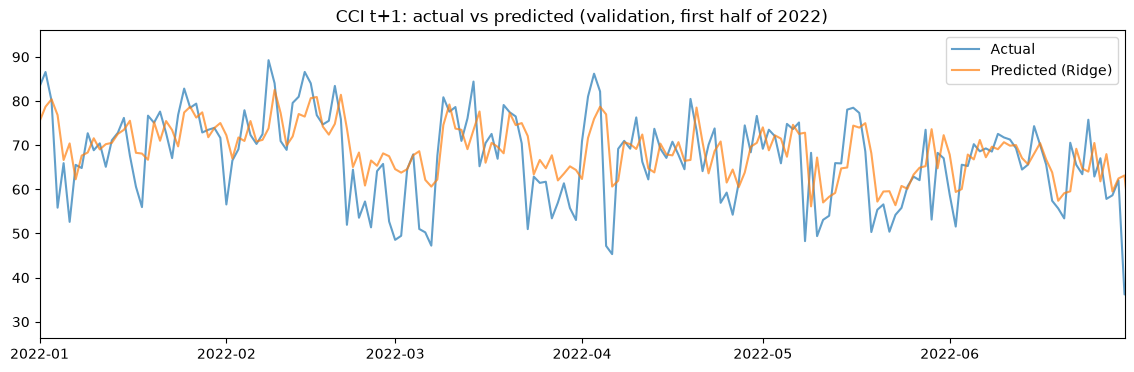

In [85]:
# <Student to fill this section>
results = []
for col in target_cols:
    print(f"\n===== {col} =====")
    print_regressor_scores(models[col].predict(X_train), y_train[col], 'Training')
    val_scores = print_regressor_scores(models[col].predict(X_val), y_val[col], 'Validation')
    results.append({'target': col, 'model': 'Ridge', **val_scores})
    for b in ['persistence', 'climatology']:
        results.append({'target': col, 'model': b, **baseline_scores[(col, b)]})

results = pd.DataFrame(results)
os.makedirs('../../reports', exist_ok=True)
results.to_csv('../../reports/cci_exp1_results.csv', index=False)

print("\nValidation RMSE:")
print(results.pivot(index='model', columns='target', values='rmse').round(3))

coefs = pd.Series(models['cci_t_plus_1'].named_steps['ridge'].coef_, index=feature_cols)
print("\nTop 10 coefficients (t+1):")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10).round(3))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_val, y_val['cci_t_plus_1'], label='Actual', alpha=0.7)
ax.plot(dates_val, models['cci_t_plus_1'].predict(X_val), label='Predicted (Ridge)', alpha=0.7)
ax.set_xlim(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-06-30'))
ax.set_title('CCI t+1: actual vs predicted (validation, first half of 2022)')
ax.legend()
plt.show()

In [99]:
# <Student to fill this section>
model_performance_explanations = """
Validation results (RMSE, compared with the best baseline for each horizon):
- Day 1: RMSE 8.59 (MAE 6.35, R2 0.37), 11.4 percent better than persistence (9.70) and 23.3 percent better
  than climatology (11.21).
- Day 2: RMSE 10.04 (MAE 7.55, R2 0.13), 10.5 percent better than climatology (11.21), the best baseline here.
- Day 3: RMSE 10.52 (MAE 7.94, R2 0.05), only 6.2 percent better than climatology (11.21).

Ridge beats both baselines at every horizon, but accuracy drops sharply with the horizon: R2 falls from 0.37
to 0.05, so by day 3 the model explains very little beyond the seasonal average.

Training vs validation: the validation error is higher than the training error (e.g. day 1 RMSE 7.52 vs 8.59).
Because changing the regularisation strength barely affects the result, this gap is mainly explained by the
distribution shift in 2020-2022 (wetter, less comfortable years) rather than by overfitting.

Among the largest coefficients (day 1) are cci_roll3_mean (+1.46, recent comfort persists), doy_cos (+1.39,
higher comfort in summer) and wind_speed_10m_max (-1.39, windy days are followed by lower comfort).
"""

In [100]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [88]:
# <Student to fill this section>
val_pred = models['cci_t_plus_1'].predict(X_val)
abs_err = np.abs(val_pred - y_val['cci_t_plus_1'])
print(f"Share of days within 5 points: {(abs_err <= 5).mean():.3f}")
print(f"Share of days within 10 points: {(abs_err <= 10).mean():.3f}")

band = lambda s: pd.Series(s).apply(cci_to_label).values
print(f"Correct interpretation band: {(band(val_pred) == band(y_val['cci_t_plus_1'])).mean():.3f}")

Share of days within 5 points: 0.517
Share of days within 10 points: 0.788
Correct interpretation band: 0.709


In [97]:
# <Student to fill this section>
business_impacts_explanations = """
For the day-1 forecast on the validation period:
- 51.7 percent of forecasts are within 5 CCI points of the actual value;
- 78.8 percent are within 10 points;
- 70.9 percent fall in the correct interpretation band (e.g. Comfortable vs Excellent).

For users planning outdoor activities, the day-1 forecast is useful as a general guide: about 7 in 10 days get
the right comfort category. However, about 1 in 5 forecasts are off by more than 10 points, which can move a day
from Comfortable to Moderate or vice versa.

The most costly errors are over-forecasting comfort on poor days (e.g. an event planned on a day that turns out
rainy and uncomfortable). A linear model tends to pull predictions towards the average, so it is least reliable
on the rare low-comfort days that matter most.

Day 2 and day 3 forecasts (R2 of 0.13 and 0.05) are only slightly better than the seasonal average. They should
be presented to users as low-confidence indications, not firm forecasts.
"""

In [90]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes


In [ ]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Partially Confirmed"  # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [92]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [95]:
# <Student to fill this section>
experiment_results_explanations = """
Outcome: the hypothesis is partially confirmed. Ridge regression beats both the persistence and climatology
baselines at all three horizons (validation RMSE 8.59, 10.04 and 10.52). However, the improvement over
climatology is small for day 3 (6.2 percent, R2 0.05), and the errors remain large relative to the CCI's day-to-day
variability, so the second success criterion (forecasts usually in the correct band) is only met for day 1
(70.9 percent).

New insights:
- Recent comfort (today's CCI and short rolling means) and seasonality are the most useful signals.
- Some variables have non-linear effects that a linear model cannot capture: wind (comfort peaks at 10 km/h)
  and pressure change (almost zero linear correlation despite being a classic weather signal).
- The validation period (2020-2022) is wetter and less comfortable than the training years, a distribution
  shift that affects all models and baselines.
- Tuning alpha barely changes the results, so more regularisation is not the way forward.

Next steps, ranked by expected gain:
1. XGBoost (Experiment 2): expected to give the largest gain, by capturing non-linear effects (wind, pressure
   change, cloud) and interactions between features.
2. Hyperparameter tuning with Optuna (Experiment 3): a moderate additional gain once the best algorithm is known.
3. Retraining on 2000-2022 before final testing, so the model also learns from the recent wetter years: a small
   to moderate gain on the 2023-2025 test period.
4. Additional features (e.g. hourly patterns within the day, longer-range climate signals): uncertain gain, more
   effort.

This is not yet the final model, so it is not recommended for deployment. The pipeline (package functions,
chronological split and saved scikit-learn pipelines) is ready to reuse for the next experiments.
"""

In [96]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)